# **ReAct: Build Reasoning and Acting AI Agents with LangGraph**


Estimated time needed: **90** minutes


You're a software engineer on a mission: build an AI agent that doesn't just respond—it thinks. In this lab, you'll step into the role of an AI architect, designing a smart assistant that solves tough problems by reasoning through them and taking purposeful actions.

Using the ReAct (Reasoning + Acting) framework, you'll teach your agent to think step by step, consult tools like search engines or calculators, and adapt on the fly. It’s not just about answers—it’s about how the agent gets there.

By the end of the lab, your AI will face a mystery that can’t be solved with knowledge alone. It will need logic, resourcefulness, and the ability to act—just like you, the engineer who built it.

## What is ReAct?

**ReAct** stands for **Reasoning + Acting**. It's a framework that combines:

1. **Reasoning**: The agent thinks through problems step by step, maintaining an internal dialogue about what it needs to do.
2. **Acting**: The agent can use external tools (search engines, calculators, APIs) to gather information or perform actions.
3. **Observing**: The agent processes the results from its actions and incorporates them into its reasoning.

This creates a powerful loop: **Think → Act → Observe → Think → Act → ...**

### Why ReAct Matters

Traditional language models are limited by their training data cutoff and can't access real-time information. ReAct agents overcome this by:
- Accessing current information through web searches
- Performing calculations with specialized tools
- Breaking down complex problems into manageable steps
- Adapting their approach based on intermediate results


----


## Setup & Installation


For this lab, we will be using the following libraries:


- [`LangGraph`](https://www.langchain.com/langgraph): A framework for building stateful, multi-step AI applications using graphs.
- [`LangChain`](https://www.langchain.com/): A toolkit that provides tools and abstractions for working with language models.
- [`LangChain-OpenAI`](https://python.langchain.com/docs/integrations/llms/openai/): OpenAI integration for LangChain.
- [`LangChain-Community`](https://python.langchain.com/api_reference/community/index.html): Community-contributed tools and integrations.


### Installing Required Libraries


In [1]:
!pip install -U langgraph langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 50.7 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.12.2
    Uninstalling typing_extensions-4.12.2:
      Successfully uninstalled typing_extensions-4.12.2


In [2]:
%%capture
!pip install langgraph==0.3.34 langchain-openai==0.3.14 langchainhub==0.1.21 langchain==0.3.24 pygraphviz==1.14 langchain-community==0.3.23

### Understanding Tools in ReAct

Tools are the "acting" part of ReAct. They give the agent capabilities beyond just generating text. Let's build two essential tools:

#### 1. Web Search Tool
### Tavily Search API Key Setup

We'll use Tavily search as our external research tool. You can get an API key at https://app.tavily.com/sign-in   


**Disclaimer:** Signing up for Tavily provides you with free credits, more than enough for this project's needs. If you require additional credits for further use, please add them at your own discretion.

![image.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UjJx1-0vss4_3lwsUF8n0w/image.png)

You need to copy the key from Tavily's API website and paste the key on the line ```os.environ["TAVILY_API_KEY"] = "YOUR_KEY_HERE"```


In [3]:
import warnings
def warn(*args,**kwargs):
    pass
warnings.filterwarnings('ignore')
warnings.warn = warn

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools import tool
import os
import json

os.environ["TAVILY_API_KEY"] = "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"

# Initialize the Tavily search tool
search = TavilySearchResults()

@tool
def search_tool(query: str):
    """
    Search the web for information using Tavily API.

    :param query: The search query string
    :return: Search results related to the query
    """
    return search.invoke(query)

### Theory behind Web Search Tools:
- Enable real-time information retrieval
- Overcome the knowledge cutoff limitation of language models
- Return structured data that the agent can process and reason about

### Testing the Search Tool


In [4]:
search_tool.invoke("What's the weather like in Darmstadt today?")


[{'title': 'Darmstadt Weather Conditions: Temperature | 30 Days Forecast',
  'url': 'https://www.aqi.in/weather/germany/hesse/darmstadt',
  'content': "From 11:15 AM 28 June 2026, Darmstadt's 10-day forecast shows this trend:\nToday (Jun. 28) : Temp. 30°C, Hum. 44% and Sunny condition.\nMonday (Jun. 29) : Temp. 26°C, Hum. 67% and Patchy rain nearby condition.\nTuesday (Jun. 30) : Temp. 24°C, Hum. 72% and Patchy rain nearby condition.\nWednesday (Jul. 1) : Temp. 23°C, Hum. 58% and Sunny condition.\nThursday (Jul. 2) : Temp. 23°C, Hum. 46% and Sunny condition.\nFriday (Jul. 3) : Temp. 21°C, Hum. 47% and Sunny condition.\nSaturday (Jul. 4) : Temp. 21°C, Hum. 42% and Sunny condition.\nSunday (Jul. 5) : Temp. 19°C, Hum. 52% and Sunny condition.\nMonday (Jul. 6) : Temp. 21°C, Hum. 65% and Moderate rain at times condition.\nTuesday (Jul. 7) : Temp. 20°C, Hum. 64% and Moderate or heavy rain shower condition.\n\n4. Will it rain in Darmstadt today? [...] Here is a complete overview of Darmstadt'

This test demonstrates how the agent can access current information that wasn't available during training.

#### 2. Clothing Recommendation Tool


In [5]:
@tool
def recommend_clothing(weather: str) -> str:
    """
    Returns a clothing recommendation based on the provided weather description.

    This function examines the input string for specific keywords or temperature indicators 
    (e.g., "snow", "freezing", "rain", "85°F") to suggest appropriate attire. It handles 
    common weather conditions like snow, rain, heat, and cold by providing simple and practical 
    clothing advice.

    :param weather: A brief description of the weather (e.g., "Overcast, 64.9°F")
    :return: A string with clothing recommendations suitable for the weather
    """
    weather = weather.lower()
    if "snow" in weather or "freezing" in weather:
        return "Wear a heavy coat, gloves, and boots."
    elif "rain" in weather or "wet" in weather:
        return "Bring a raincoat and waterproof shoes."
    elif "hot" in weather or "85" in weather:
        return "T-shirt, shorts, and sunscreen recommended."
    elif "cold" in weather or "50" in weather:
        return "Wear a warm jacket or sweater."
    else:
        return "A light jacket should be fine."

**Why this Tool Matters:**
- Demonstrates domain-specific reasoning
- Shows how tools can process and interpret data from other tools
- Illustrates the composability of ReAct systems

#### Creating the Tool Registry


In [6]:
tools=[search_tool,recommend_clothing]

tools_by_name={ tool.name:tool for tool in tools}

This registry allows the agent to dynamically select and invoke the appropriate tool based on the task at hand.

## Setting Up the Language Model

### Initializing the AI Model


In [7]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

model = ChatOpenAI(model="gpt-4o-mini")

We're using GPT-4o-mini as our reasoning engine. This model will:
- Analyze user queries
- Decide which tools to use
- Process tool results
- Generate final responses

### Creating the System Prompt


In [8]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage,SystemMessage

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", """
You are a helpful AI assistant that thinks step-by-step and uses tools when needed.

When responding to queries:
1. First, think about what information you need
2. Use available tools if you need current data or specific capabilities  
3. Provide clear, helpful responses based on your reasoning and any tool results

Always explain your thinking process to help users understand your approach.
"""),
    MessagesPlaceholder(variable_name="scratch_pad")
])

**The System Prompt's Role:**
- Defines the agent's behavior and personality
- Establishes the reasoning pattern (think → act → observe)
- Encourages transparency in the decision-making process

### Binding Tools to the Model


In [9]:
model_react=chat_prompt|model.bind_tools(tools)

In [12]:
dummy_state: AgentState = {
    "messages": [HumanMessage( "What's the weather like in Zurich, and what should I wear based on the temperature?")]}

response = model_react.invoke({"scratch_pad":dummy_state["messages"]})

dummy_state["messages"]=add_messages(dummy_state["messages"],[response])

## Automating ReAct with Graphs

### Why Use Graphs?

Manual ReAct execution is educational but impractical for real applications. LangGraph automates this process with a state machine that handles the reasoning loop automatically.

### Building the Core Functions

#### Tool Execution Node


In [16]:
def tool_node(state: AgentState):
    """Execute all tool calls from the last message in the state."""
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

**Function Purpose:**
- Automatically execute all tool calls from the model
- Handle multiple simultaneous tool calls
- Return properly formatted tool messages


#### Model Invocation Node


In [17]:
def call_model(state: AgentState):
    """Invoke the model with the current conversation state."""
    response = model_react.invoke({"scratch_pad": state["messages"]})
    return {"messages": [response]}

**Function Purpose:**
- Call the ReAct-enabled model
- Pass the full conversation context
- Return the model's response (which may include tool calls)

#### Decision Logic


In [18]:
def should_continue(state: AgentState):
    """Determine whether to continue with tool use or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

**Function Purpose:**
- Implement the control flow logic
- Decide whether the agent needs to use more tools
- Route the conversation to either tool execution or completion

### Constructing the State Graph


In [19]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Add edges between nodes
workflow.add_edge("tools", "agent")  # After tools, always go back to agent

# Add conditional logic
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",  # If tools needed, go to tools node
        "end": END,          # If done, end the conversation
    },
)

# Set entry point
workflow.set_entry_point("agent")

# Compile the graph
graph = workflow.compile()

**Graph Structure Explained:**
1. **Agent Node**: Where reasoning happens and tool calls are generated.
2. **Tools Node**: Where tool execution occurs.
3. **Conditional Edge**: Determines whether to continue or finish.
4. **Entry Point**: Conversation always starts with the agent reasoning.
### Visualizing the Graph


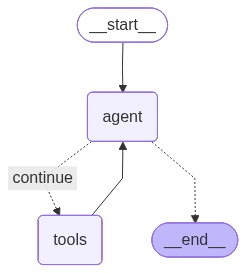

In [20]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

This visualization shows the flow: Agent → Decision → Tools → Agent → Decision → End


## Running the Complete ReAct Agent

### Final Execution


In [21]:
def print_stream(stream):
    """Helper function for formatting the stream nicely."""
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [HumanMessage(content="What's the weather like in Darmstadt, and what should I wear based on the temperature?")]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What's the weather like in Darmstadt, and what should I wear based on the temperature?
================================== Ai Message ==================================
Tool Calls:
  search_tool (call_X0dIOtg1efa3dUPbRFMZA4FD)
 Call ID: call_X0dIOtg1efa3dUPbRFMZA4FD
  Args:
    query: current weather in Darmstadt
================================= Tool Message =================================
Name: search_tool

[{"title": "Darmstadt Weather Conditions: Temperature | 30 Days Forecast", "url": "https://www.aqi.in/weather/germany/hesse/darmstadt", "content": "Here is a complete overview of Darmstadt's current weather conditions as of 11:15 AM 28 June 2026:\nCondition : Sunny\nTemperature : 33\u00b0C Hot (Feels like 35\u00b0C)\nHumidity : 36%\nWind Speed : 13.7 km/h from W (265 degrees), Gust 4.4 m/s\nUV Index : 5.9 (High\nAir Pressure : 1018 mb\nCloud Cover : 0%\nVisibility : 10 km\nPrecipitation : 0 mm (17% 

## Key Takeaways


### What Makes ReAct Powerful

1. **Transparency**: You can see the agent's reasoning process.
2. **Adaptability**: The agent can handle unexpected results and change course.
3. **Extensibility**: It's easy to add new tools and capabilities.
4. **Reliability**: The structured approach reduces hallucination and improves accuracy


### Best Practices

1. **Tool Design**: Make tools focused and reliable.
2. **Error Handling**: Plan for tool failures and unexpected results.
3. **Context Management**: Keep state manageable and relevant.
4. **User Experience**: Provide clear feedback about what the agent is doing.

The ReAct framework represents a significant step toward more capable and trustworthy AI agents that can reason through complex problems and take meaningful actions in the real world.


## Build a Calculator Tool



In [22]:
import math
import ast
import operator

@tool
def calculator_tool(expression: str) -> str:
    """
    Safely evaluate mathematical expressions.
    
    :param expression: A mathematical expression as a string (e.g., "2 + 3 * 4")
    :return: The result of the calculation
    """
    # TODO: Implement safe mathematical evaluation
    # Hint: You can use ast.literal_eval for simple expressions
    # or create a safe evaluator for more complex math
    try:
        res = eval(str)
    except ValueError as e:
        print("Error:", e)
    

# TODO: Add calculator_tool to your tools list
# TODO: Test with the agent: "What's 15% of 250 plus the square root of 144?"

In [23]:
!pip install newspaper3k
!pip install feedparser

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 127.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... one
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 153.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 140.6 MB/s eta 0:00:00
  Created wheel for tinysegmenter: filename=tinysegmenter-0.3-py3-none-any.whl size=13586 sha256=32b25354d0dacd00098d73e5a3753731ba4a638c44a0284fcdfa623eafe7cc0d
  Stored in directory: /home/jupyterlab/.cache/pip/wheels/a5/91/9f/00d66475960891a64867914273fcaf78df6cb04d905b104a2a
  Created wheel for feedfinder2: filename=feedfinder2-0.0.4-py3-none-any.whl size=3394 sha256=83c6051fb23e67cd54e190b3a30b049dfde9b9df734c7d61620390b63206a3de
  Stored in directory: /home/jupyterlab/.cache/pip/wheels/9f/9f/fb/364871d7426d3cdd4d

In [24]:
def scrape_news_from_feed(feed_url):
    articles = []
    feed = feedparser.parse(feed_url)
    for entry in feed.entries:
        # create a newspaper article object
        article = newspaper.Article(entry.link)
        # download and parse the article
        article.download()
        article.parse()
        # extract relevant information
        articles.append({
            'title': article.title,
            'author': article.authors,
            'publish_date': article.publish_date,
            'content': article.text
        })
    return articles

## Create a News Summary Tool



In [25]:
from __future__ import annotations

import json
import re
from typing import Any

from langchain_core.tools import tool


def _clean_text(value: Any) -> str:
    """Convert a value into clean single-spaced text."""
    if value is None:
        return ""

    text = str(value)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def _parse_news_content(news_content: str) -> list[dict[str, str]]:
    """
    Parse raw web-search output into normalized article dictionaries.

    Supports:
    - JSON lists
    - JSON objects containing a `results` or `articles` list
    - Plain-text article blocks
    """
    news_content = news_content.strip()

    if not news_content:
        return []

    # First attempt: parse structured JSON returned by the web-search tool.
    try:
        payload = json.loads(news_content)

        if isinstance(payload, dict):
            raw_articles = (
                payload.get("results")
                or payload.get("articles")
                or payload.get("items")
                or [payload]
            )
        elif isinstance(payload, list):
            raw_articles = payload
        else:
            raw_articles = []

        articles: list[dict[str, str]] = []

        for item in raw_articles:
            if not isinstance(item, dict):
                continue

            articles.append(
                {
                    "title": _clean_text(
                        item.get("title")
                        or item.get("headline")
                        or item.get("name")
                    ),
                    "date": _clean_text(
                        item.get("published_date")
                        or item.get("publishedAt")
                        or item.get("date")
                        or item.get("published")
                    ),
                    "source": _clean_text(
                        item.get("source")
                        or item.get("domain")
                        or item.get("publisher")
                    ),
                    "url": _clean_text(
                        item.get("url")
                        or item.get("link")
                    ),
                    "content": _clean_text(
                        item.get("raw_content")
                        or item.get("content")
                        or item.get("description")
                        or item.get("snippet")
                        or item.get("text")
                    ),
                }
            )

        return [
            article
            for article in articles
            if article["title"] or article["content"]
        ]

    except json.JSONDecodeError:
        pass

    # Second attempt: parse plain text separated by blank lines or markers.
    blocks = re.split(
        r"\n\s*(?:---+|ARTICLE\s+\d+|RESULT\s+\d+)\s*\n|\n{2,}",
        news_content,
        flags=re.IGNORECASE,
    )

    articles = []

    for block in blocks:
        block = block.strip()

        if not block:
            continue

        fields = {
            "title": "",
            "date": "",
            "source": "",
            "url": "",
            "content": "",
        }

        remaining_lines: list[str] = []

        for line in block.splitlines():
            line = line.strip()

            match = re.match(
                r"^(title|headline|date|published|source|url|link|content|summary)"
                r"\s*:\s*(.*)$",
                line,
                flags=re.IGNORECASE,
            )

            if not match:
                remaining_lines.append(line)
                continue

            key = match.group(1).lower()
            value = _clean_text(match.group(2))

            if key in {"title", "headline"}:
                fields["title"] = value
            elif key in {"date", "published"}:
                fields["date"] = value
            elif key == "source":
                fields["source"] = value
            elif key in {"url", "link"}:
                fields["url"] = value
            elif key in {"content", "summary"}:
                fields["content"] = value

        if remaining_lines:
            additional_content = _clean_text(" ".join(remaining_lines))

            if fields["content"]:
                fields["content"] += " " + additional_content
            else:
                fields["content"] = additional_content

        if fields["title"] or fields["content"]:
            articles.append(fields)

    return articles


def _remove_duplicate_articles(
    articles: list[dict[str, str]],
) -> list[dict[str, str]]:
    """Remove duplicate articles using URL and normalized title."""

    unique_articles: list[dict[str, str]] = []
    seen: set[str] = set()

    for article in articles:
        url = article["url"].lower().rstrip("/")
        normalized_title = re.sub(
            r"[^a-z0-9]+",
            "",
            article["title"].lower(),
        )

        identity = url or normalized_title

        if not identity or identity in seen:
            continue

        seen.add(identity)
        unique_articles.append(article)

    return unique_articles


def _extract_main_points(content: str, limit: int = 3) -> list[str]:
    """
    Produce an extractive summary by selecting informative sentences.

    This version requires no additional LLM call.
    """
    sentences = re.split(
        r"(?<=[.!?])\s+",
        _clean_text(content),
    )

    sentences = [
        sentence.strip()
        for sentence in sentences
        if len(sentence.strip()) >= 40
    ]

    return sentences[:limit]


@tool
def news_summarizer_tool(news_content: str) -> str:
    """
    Parse and summarize news articles from web-search results.

    Args:
        news_content:
            Raw JSON or plain-text output returned by the web-search tool.

    Returns:
        A formatted summary containing headlines, dates, sources,
        main points and source URLs.
    """
    articles = _parse_news_content(news_content)
    articles = _remove_duplicate_articles(articles)

    if not articles:
        return "No valid news articles were found in the supplied content."

    output: list[str] = ["## News summary"]

    for index, article in enumerate(articles, start=1):
        title = article["title"] or f"Article {index}"
        points = _extract_main_points(article["content"])

        output.append(f"\n### {index}. {title}")

        if article["date"]:
            output.append(f"**Date:** {article['date']}")

        if article["source"]:
            output.append(f"**Source:** {article['source']}")

        if points:
            output.extend(f"- {point}" for point in points)
        else:
            output.append("- No usable article description was supplied.")

        if article["url"]:
            output.append(f"**URL:** {article['url']}")

    return "\n".join(output)

## Testing Your Solutions

For each exercise, test your implementation with these commands:


In [26]:
# Exercise 1 Test
inputs = {"messages": [HumanMessage(content="Calculate 15% of 250 plus the square root of 144")]}
print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Calculate 15% of 250 plus the square root of 144
================================== Ai Message ==================================

To calculate \( 15\% \) of \( 250 \) plus the square root of \( 144 \), we can break it down into two parts:

1. Calculate \( 15\% \) of \( 250 \):
   \[
   15\% = \frac{15}{100} = 0.15
   \]
   Therefore:
   \[
   0.15 \times 250 = 37.5
   \]

2. Calculate the square root of \( 144 \):
   \[
   \sqrt{144} = 12
   \]

Now we can add these two results together:
\[
37.5 + 12 = 49.5
\]

Thus, \( 15\% \) of \( 250 \) plus the square root of \( 144 \) is \( 49.5 \).


In [ ]:
# Exercise 2 Test  
inputs = {"messages": [HumanMessage(content="Find recent AI news and summarize the top 3 articles")]}
print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Find recent AI news and summarize the top 3 articles
================================== Ai Message ==================================
Tool Calls:
  search_tool (call_x3mXZFbnVDREWySPlUn43jqw)
 Call ID: call_x3mXZFbnVDREWySPlUn43jqw
  Args:
    query: recent AI news
================================= Tool Message =================================
Name: search_tool

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com", "content": "Retail & Logistics AI\n\nJune 11, 2026\n\n### How C3 AI agents will automate predictive maintenance for Shell\n\nAI in Action\n\nJune 5, 2026\n\n#### Industries\n\n### Omio scales travel product development using OpenAI models\n\nAI in Action\n\nJune 23, 2026\n\n### L\u2019Or\u00e9al brings Maybelline virtual try-on to ChatGPT\n\nAI in Action\n\nJune 22, 2026\n\n### SAP and Google Cloud deploy agentic